### XGBoost regression



### California Housing Prices Project 


In [2]:
# Check if all dependencies and environment is ready

installed_env = !pip list
installed_env

['Package                   Version',
 '------------------------- -----------',
 'anyio                     4.10.0',
 'argon2-cffi               25.1.0',
 'argon2-cffi-bindings      25.1.0',
 'asttokens                 3.0.0',
 'async-lru                 2.0.5',
 'attrs                     25.4.0',
 'babel                     2.17.0',
 'beautifulsoup4            4.14.3',
 'bleach                    6.3.0',
 'brotlicffi                1.2.0.0',
 'certifi                   2026.1.4',
 'cffi                      2.0.0',
 'charset-normalizer        3.4.4',
 'chart-studio              1.1.0',
 'colorama                  0.4.6',
 'colorlover                0.3.0',
 'comm                      0.2.3',
 'contourpy                 1.3.3',
 'cufflinks                 0.17.3',
 'cycler                    0.12.1',
 'debugpy                   1.8.16',
 'decorator                 5.2.1',
 'defusedxml                0.7.1',
 'executing                 2.2.1',
 'fastjsonschema            2.21.2',
 'fon

In [3]:
# sklearn is missing, we import it

!pip install scikit-learn

In [4]:
# Import libraries and dataset

import numpy as np
import pandas as pd
from sklearn import datasets

# Import California Housing Data set
housingX, housingy = datasets.fetch_california_housing (
    return_X_y=True, as_frame=True)  # fetch_california_housing is indeed a method in scikit-learn, specifically in the sklearn.datasets module.


In [5]:
housingX.head()   # features

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
housingy.head()  # target

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

Text(0.5, 1.0, 'Distribution of Target Variable (House Values)')

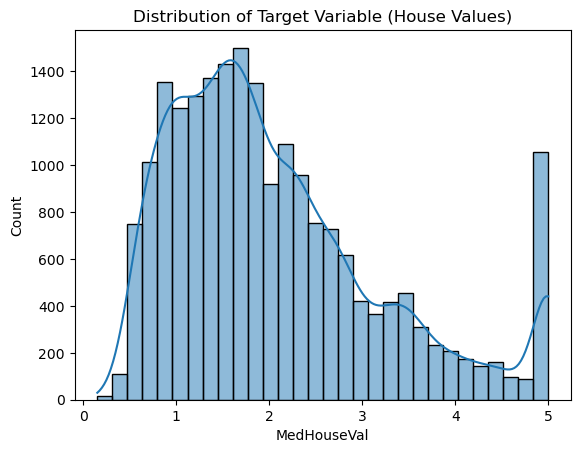

In [7]:
#plot a histogram of the target variable

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(housingy, bins=30, kde=True)
plt.title('Distribution of Target Variable (House Values)')

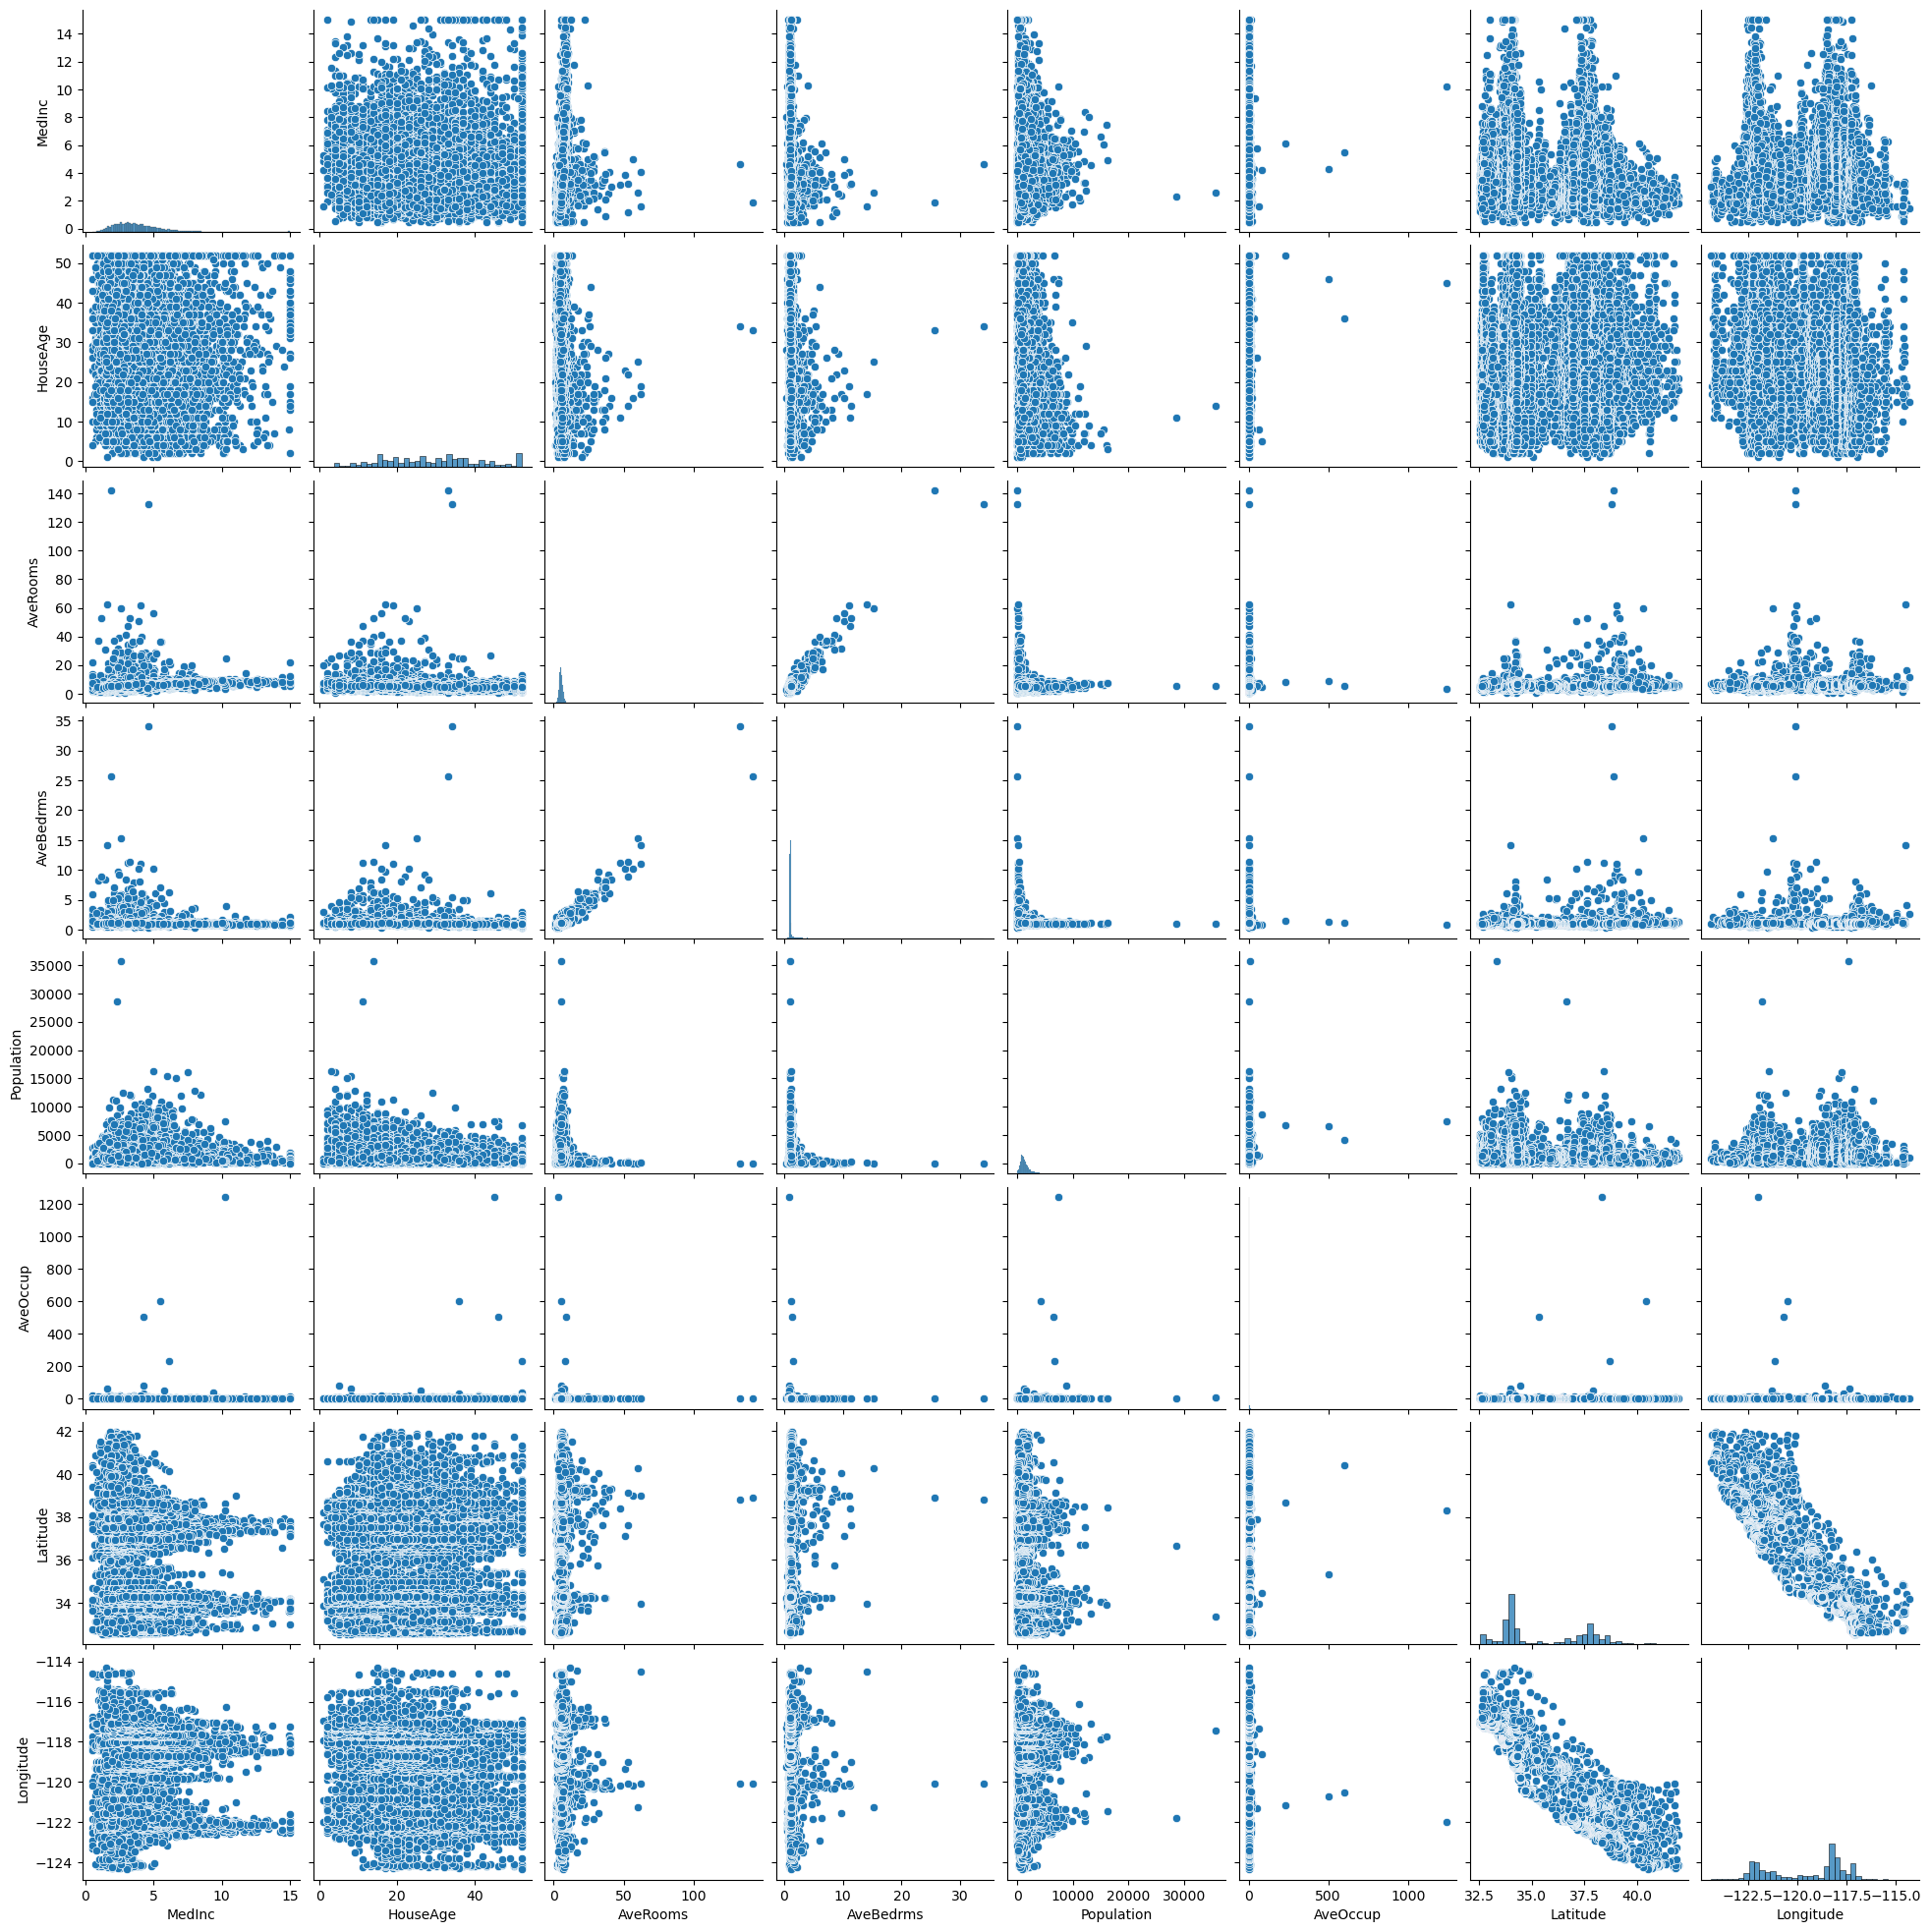

In [8]:
#investigate relationship between housingX features using a pairplot

sns.pairplot(housingX)

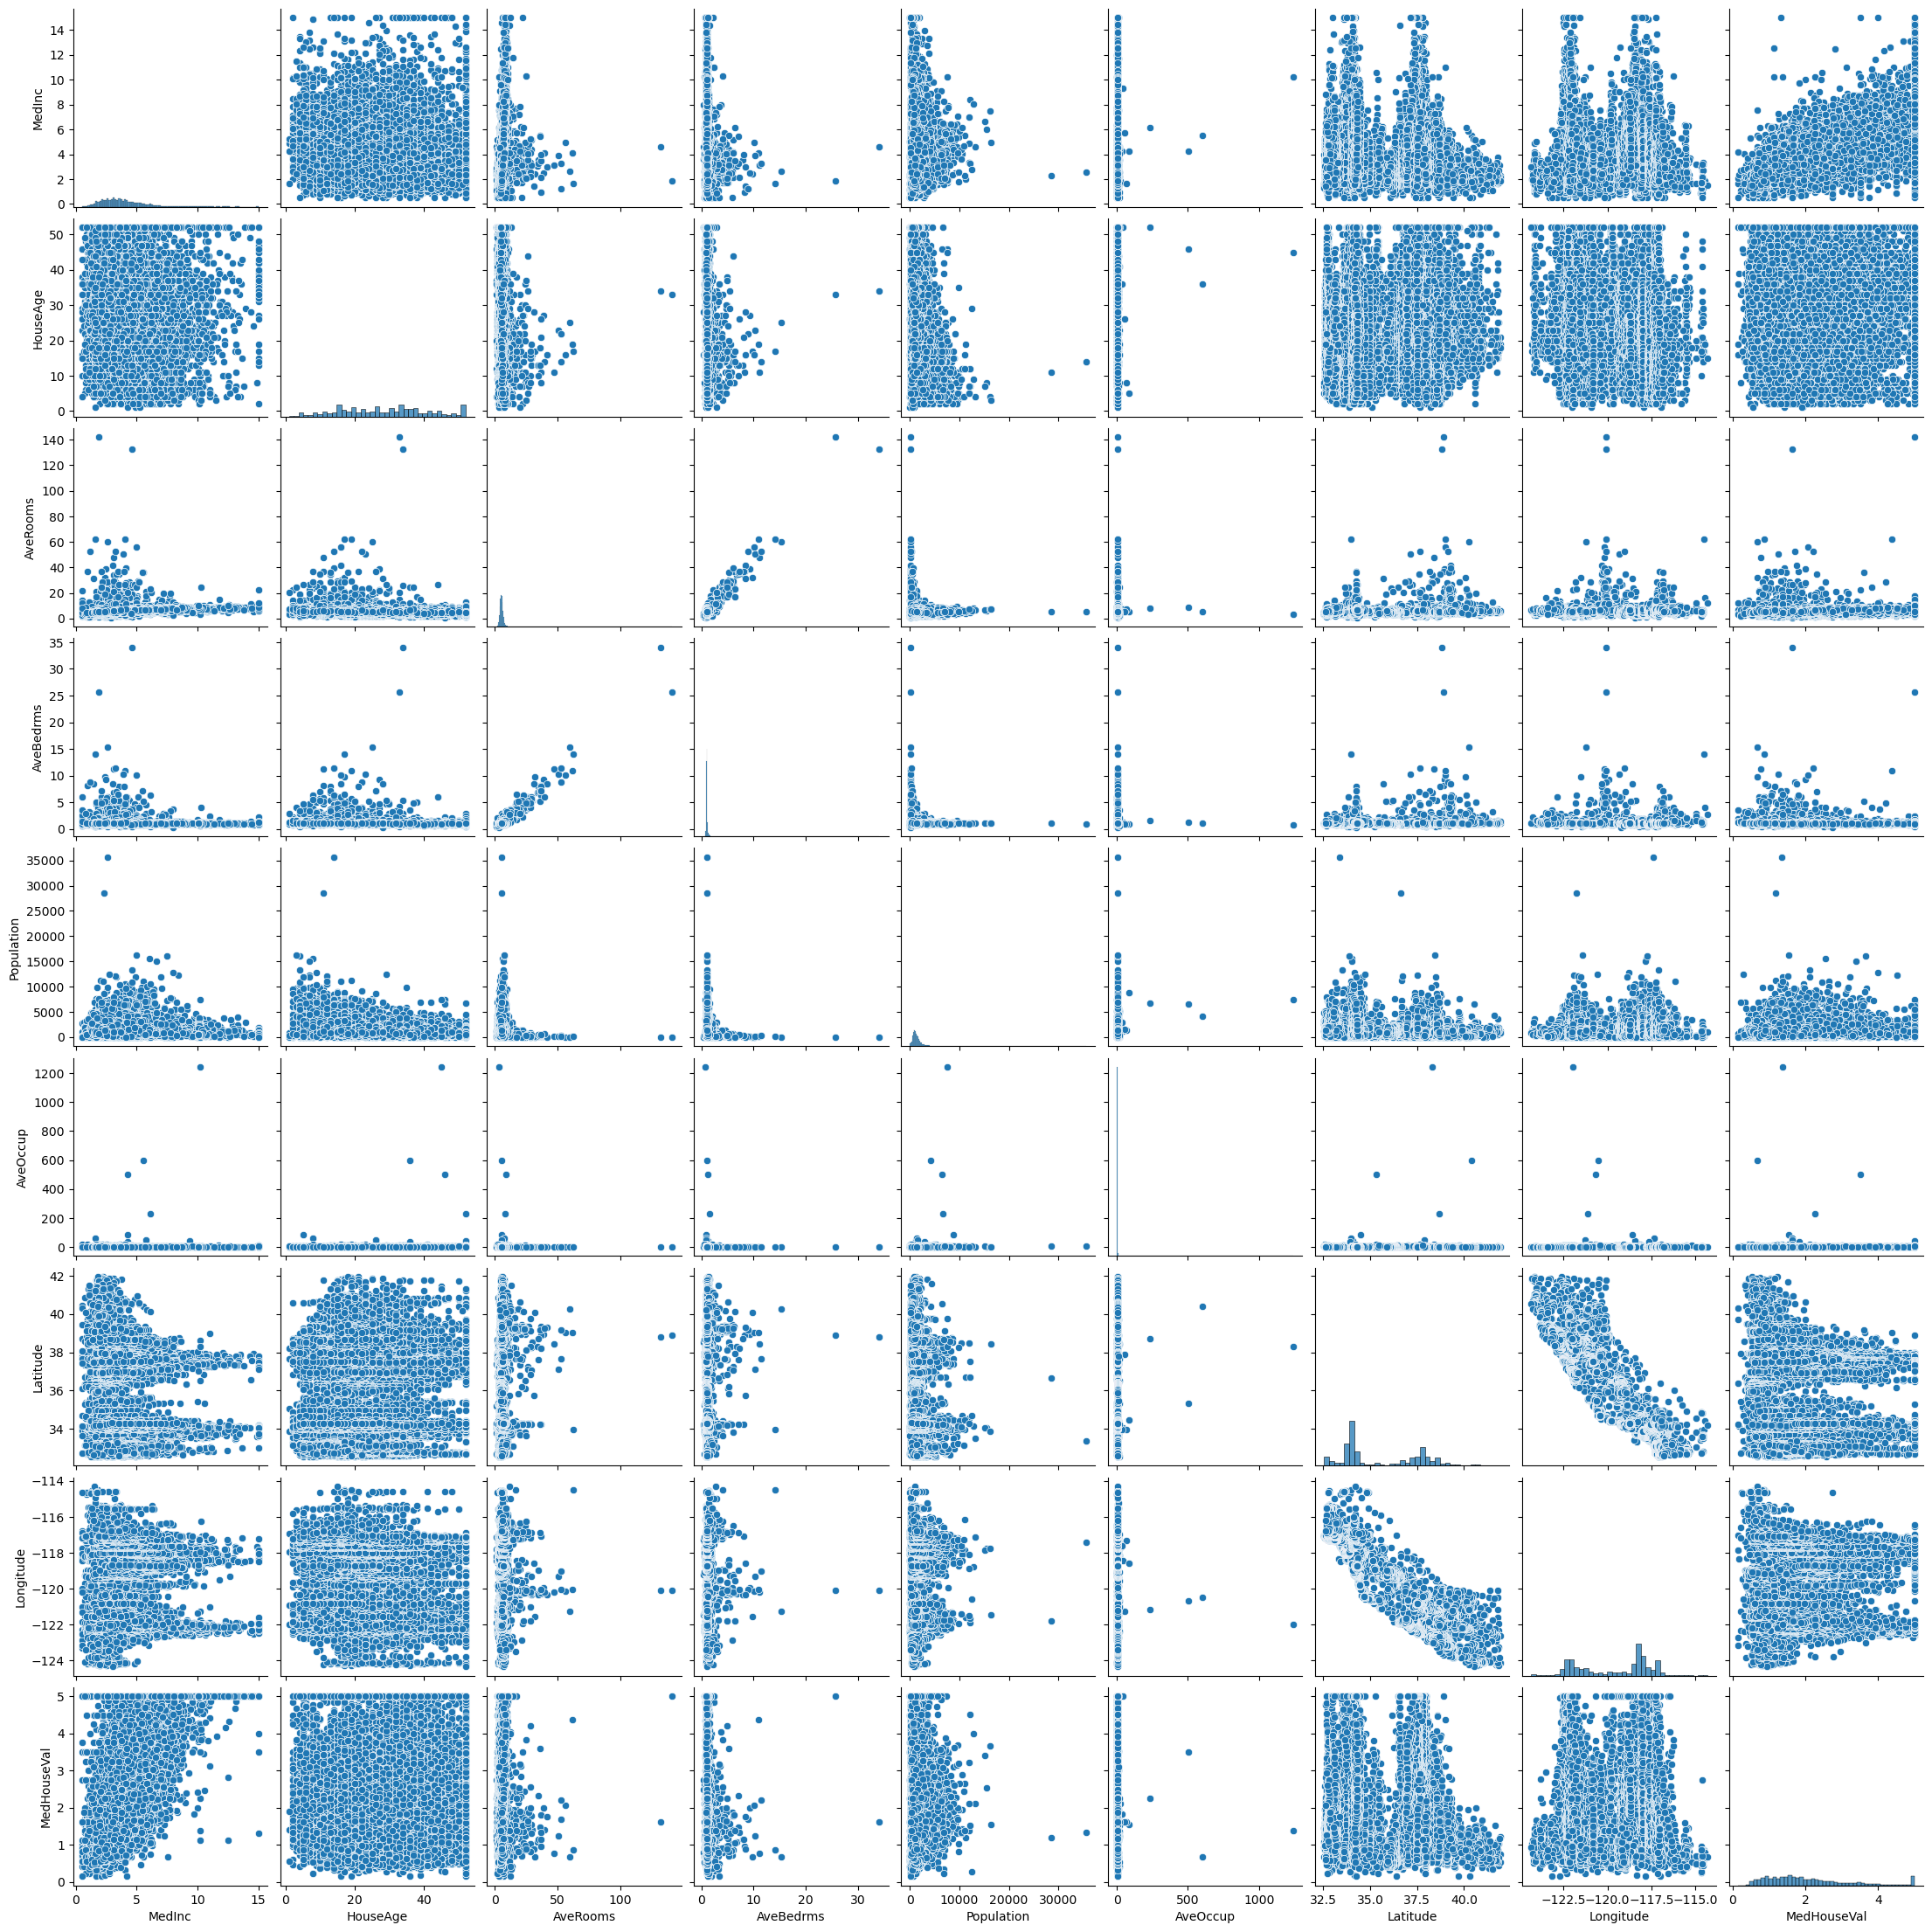

In [9]:
# investigate r/ship b/n Features and Target variables
joined_pairplot = pd.concat([housingX, housingy], axis=1)
sns.pairplot(joined_pairplot)

In [40]:
#prepare data for predictive modeling
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(housingX, housingy, test_size=0.2, random_state=42)

In [41]:
# count rows of original data
count_row_original = housingX.value_counts().sum()
print(f"Number of rows in original data: {count_row_original}")
# count rows of training data
count_row_train = X_train.value_counts().sum()
print(f"Number of rows in training data: {count_row_train}")
#check percentage of training data : original data
percent = (count_row_train / count_row_original) * 100
print(f"Percentage of training data: {percent:.2f}%")   

Number of rows in original data: 20640
Number of rows in training data: 16512
Percentage of training data: 80.00%


In [42]:
# Train an XGboost Regressor model
import xgboost as xgb
from sklearn.metrics import r2_score, root_mean_squared_error

# Initialize an xgboost regressor
xgb_regressor = xgb.XGBRegressor()

#Fit the xgb regressor
xgb_regressor.fit(X_train, y_train)

# Make predictions
y_pred = xgb_regressor.predict(X_test)



In [43]:
# Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f' r2_score= {r2:.4f}')
print(f' root_mean_squared_error= {rmse:.4f}')

 r2_score= 0.8301
 root_mean_squared_error= 0.4718


## So What if we want to predict house price based on certain values, given a single row of data?

MedInc = 12.5, HouseAge = 10, AveRooms = 9 , AveBedrms = 3, Population = 4000, AveOccup = 3, Latitude = 33.98, Longitude = -118.45

In [44]:
data = {'MedInc': [12.5], 'HouseAge' : [10], 'AveRooms': [9] , 'AveBedrms': [3], 'Population': [4000], 
        'AveOccup': [3], 'Latitude': [33.98], 'Longitude': [-118.45]}
new_data = pd.DataFrame(data) 

In [45]:
new_data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,12.5,10,9,3,4000,3,33.98,-118.45


In [46]:
housingX.head(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.02381,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.97188,2401.0,2.109842,37.86,-122.22


# The new_data table has columns ordered similar to original data, we can therefore use it for prediction 


In [47]:
# Prediction for new data
new_prediction = xgb_regressor.predict(new_data)

In [48]:
print(new_prediction)

[5.1877832]
